In [1]:
import pandas as pd
import numpy as np

# --------- CONFIG ----------
ID_COL    = "id"
pubtime  = "pubtime"          # <-- keep date info
THEME_COL = "main_theme"
SENT_COL  = "sentiment_label"

SENT_ORDER = ["NEGATIVE", "NEUTRAL", "POSITIVE"]
MIXED_THRESHOLD = 0.55

CSV_PATH = "2025_ROBERTA_ANALYSIS.csv"
df_sentences = pd.read_csv(CSV_PATH)

# ---------- checks ----------
for col in [ID_COL, pubtime, THEME_COL, SENT_COL]:
    if col not in df_sentences.columns:
        raise ValueError(f"Missing required column '{col}'. Columns found: {list(df_sentences.columns)}")

# keep required cols, keep pubtime
df = df_sentences[[ID_COL, pubtime, THEME_COL, SENT_COL]].copy()

# parse pubtime -> datetime (keep as datetime)
df[pubtime] = pd.to_datetime(df[pubtime], errors="coerce")

# normalize labels
df[THEME_COL] = df[THEME_COL].astype(str).str.strip()
df[SENT_COL]  = df[SENT_COL].astype(str).str.strip().str.upper()

# keep only known sentiment labels (drop anything else)
df = df[df[SENT_COL].isin(SENT_ORDER)].copy()

# --------------------------------------------------------------
# Helper: dominant label with MIXED rule
# --------------------------------------------------------------
def dominant_label_from_row_counts(row: pd.Series, mixed_threshold: float) -> str:
    total = row.sum()
    if total == 0:
        return np.nan
    top = row.idxmax()
    share = row.max() / total
    return top if share >= mixed_threshold else "Other"

# ==============================================================
# 0) ARTICLE DATE aggregation (keep a stable article-level pubtime)
# ==============================================================
# If pubtime is identical for all sentences of an article, this is fine.
# If not (duplicates / parsing issues), we keep the earliest non-null pubtime.
article_pubtime = (
    df.dropna(subset=[pubtime])
      .groupby(ID_COL)[pubtime]
      .min()
      .rename(pubtime)
)

# ==============================================================
# 1) SENTIMENT aggregation (vectorized, robust)
# ==============================================================
sent_counts = (
    df.groupby(ID_COL)[SENT_COL]
      .value_counts()
      .unstack(fill_value=0)
)

# collapse duplicate columns if any
sent_counts = sent_counts.groupby(level=0, axis=1).sum()

# ensure all required sentiment columns exist
for lab in SENT_ORDER:
    if lab not in sent_counts.columns:
        sent_counts[lab] = 0

sent_counts = sent_counts[SENT_ORDER].copy()
sent_counts["n_sentences"] = sent_counts.sum(axis=1)

den = sent_counts["n_sentences"].replace(0, np.nan)
sent_counts["neg_share"] = sent_counts["NEGATIVE"] / den
sent_counts["neu_share"] = sent_counts["NEUTRAL"] / den
sent_counts["pos_share"] = sent_counts["POSITIVE"] / den

sent_counts["dominant_sentiment_roberta"] = sent_counts[SENT_ORDER].apply(
    lambda r: dominant_label_from_row_counts(r, MIXED_THRESHOLD),
    axis=1
)

sent_counts = sent_counts.rename(columns={
    "NEGATIVE": "n_negative",
    "NEUTRAL": "n_neutral",
    "POSITIVE": "n_positive",
})

# ==============================================================
# 2) THEME aggregation
# ==============================================================
theme_counts = (
    df.groupby(ID_COL)[THEME_COL]
      .value_counts()
      .unstack(fill_value=0)
)

theme_counts = theme_counts.groupby(level=0, axis=1).sum()

theme_total = theme_counts.sum(axis=1).replace(0, np.nan)
theme_shares = theme_counts.div(theme_total, axis=0)

dominant_theme = theme_shares.idxmax(axis=1)
dominant_theme_share = theme_shares.max(axis=1)
dominant_theme = dominant_theme.where(dominant_theme_share >= MIXED_THRESHOLD, "MIXED")

def entropy_from_counts(row: pd.Series) -> float:
    vals = row.values.astype(float)
    s = vals.sum()
    if s == 0:
        return np.nan
    p = vals / s
    p = p[p > 0]
    return float(-(p * np.log(p)).sum())

theme_entropy = theme_counts.apply(entropy_from_counts, axis=1)
n_themes_nonzero = (theme_counts > 0).sum(axis=1)

# ==============================================================
# 3) FINAL article-level dataset (with pubtime)
# ==============================================================
df_article_roberta = (
    sent_counts.reset_index()
    .merge(article_pubtime.reset_index(), on=ID_COL, how="left")
    .merge(
        pd.DataFrame({
            ID_COL: theme_counts.index,
            "dominant_theme_roberta": dominant_theme.values,
            "n_themes_nonzero": n_themes_nonzero.values,
            "theme_entropy": theme_entropy.values,
        }),
        on=ID_COL,
        how="left"
    )
)

# reorder
cols_order = [
    ID_COL,
    pubtime,
    "dominant_theme_roberta",
    "dominant_sentiment_roberta",
    "n_sentences",
    "n_negative", "n_neutral", "n_positive",
    "neg_share", "neu_share", "pos_share",
    "n_themes_nonzero", "theme_entropy",
]
df_article_roberta = df_article_roberta[[c for c in cols_order if c in df_article_roberta.columns]]

df_article_roberta.head()


/var/folders/dv/g77m5t256rs8h3zskyc3gtbw0000gn/T/ipykernel_1682/3109449063.py:67: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  sent_counts = sent_counts.groupby(level=0, axis=1).sum()
/var/folders/dv/g77m5t256rs8h3zskyc3gtbw0000gn/T/ipykernel_1682/3109449063.py:102: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  theme_counts = theme_counts.groupby(level=0, axis=1).sum()


,id,pubtime,dominant_theme_roberta,dominant_sentiment_roberta,n_sentences,n_negative,n_neutral,n_positive,neg_share,neu_share,pos_share,n_themes_nonzero,theme_entropy
0,52630283,2025-02-05,Others,NEUTRAL,2,0,2,0,0.000000,1.000000,0.0,1,-0.0
1,55698005,2025-01-01,Research,NEUTRAL,3,0,3,0,0.000000,1.000000,0.0,1,-0.0
2,55698135,2025-01-01,Transports,NEUTRAL,2,0,2,0,0.000000,1.000000,0.0,1,-0.0
3,55698329,2025-01-01,Others,NEUTRAL,3,1,2,0,0.333333,0.666667,0.0,1,-0.0
4,55699006,2025-01-01,Others,NEGATIVE,4,3,1,0,0.750000,0.250000,0.0,1,-0.0


In [2]:
# ============================================================
# COMPARE: df_article_roberta  (derived from sentence-level)
#      VS df_apertus          (LLM at article-level)
# - % match for topic + sentiment
# - confusion matrices
# - distributions (counts + shares) side-by-side
# ============================================================

import pandas as pd
import numpy as np

# ------------- CONFIG: set your column names here -------------
ID_COL = "id"

# apertus (LLM) columns
TOPIC_LLM_COL = "topic_llm"
SENT_LLM_COL  = "sentiment_public_admin_llm"   # change if needed

# roberta (article-agg) columns
TOPIC_ROB_COL = "dominant_theme_roberta"       # or "main_theme_roberta" if you used another name
SENT_ROB_COL  = "dominant_sentiment_roberta"

# Optional: if labels differ across systems, map to a shared taxonomy here
TOPIC_MAP_LLM = {}      # e.g. {"EJPD": "DFJP / EJPD", ...}
TOPIC_MAP_ROB = {}      # e.g. {"DFJP / EJPD – Justice et police": "EJPD", ...}

SENT_MAP_LLM = {}       # e.g. {"NEG": "NEGATIVE", "POS": "POSITIVE"}
SENT_MAP_ROB = {}       # usually already NEGATIVE/NEUTRAL/POSITIVE

# ------------- helper functions -------------
def normalize_series(s: pd.Series) -> pd.Series:
    return (s.astype(str)
             .str.strip()
             .str.replace(r"\s+", " ", regex=True))

def apply_map(s: pd.Series, mapping: dict) -> pd.Series:
    if mapping:
        return s.map(lambda x: mapping.get(x, x))
    return s

def match_rate(a: pd.Series, b: pd.Series) -> float:
    m = a.notna() & b.notna()
    if m.sum() == 0:
        return np.nan
    return float((a[m] == b[m]).mean())

def dist_table(s: pd.Series, name: str) -> pd.DataFrame:
    vc = s.value_counts(dropna=False)
    out = pd.DataFrame({
        f"{name}_count": vc,
        f"{name}_share": vc / vc.sum()
    })
    return out

# ------------- 0) Sanity checks -------------
CSV_PATH = "2025_APERTUS_ANALYSIS.csv"
df_apertus = pd.read_csv(CSV_PATH)

for col in [ID_COL, TOPIC_ROB_COL, SENT_ROB_COL]:
    if col not in df_article_roberta.columns:
        raise ValueError(f"df_article_roberta missing '{col}'. Found: {list(df_article_roberta.columns)}")

for col in [ID_COL, TOPIC_LLM_COL, SENT_LLM_COL]:
    if col not in df_apertus.columns:
        raise ValueError(f"df_apertus missing '{col}'. Found: {list(df_apertus.columns)}")


# ------------- 1) Merge -------------
df_cmp = (
    df_article_roberta[[ID_COL, TOPIC_ROB_COL, SENT_ROB_COL]].copy()
    .merge(
        df_apertus[[ID_COL, TOPIC_LLM_COL, SENT_LLM_COL]].copy(),
        on=ID_COL,
        how="inner",
        suffixes=("_rob", "_llm")
    )
)

# normalize strings
df_cmp[TOPIC_ROB_COL] = normalize_series(df_cmp[TOPIC_ROB_COL])
df_cmp[TOPIC_LLM_COL] = normalize_series(df_cmp[TOPIC_LLM_COL])
df_cmp[SENT_ROB_COL]  = normalize_series(df_cmp[SENT_ROB_COL]).str.upper()
df_cmp[SENT_LLM_COL]  = normalize_series(df_cmp[SENT_LLM_COL]).str.upper()

# apply mapping if needed
df_cmp["topic_roberta_std"] = apply_map(df_cmp[TOPIC_ROB_COL], TOPIC_MAP_ROB)
df_cmp["topic_llm_std"]     = apply_map(df_cmp[TOPIC_LLM_COL], TOPIC_MAP_LLM)
df_cmp["sent_roberta_std"]  = apply_map(df_cmp[SENT_ROB_COL],  SENT_MAP_ROB)
df_cmp["sent_llm_std"]      = apply_map(df_cmp[SENT_LLM_COL],  SENT_MAP_LLM)

# Harmonisation labels topic
df_cmp["topic_llm_std"] = df_cmp["topic_llm_std"].replace({
    "Others": "Other",   # au cas où
})

df_cmp["topic_roberta_std"] = df_cmp["topic_roberta_std"].replace({
    "Others": "Other",
})

# ------------- 2) Match rates -------------
topic_match = match_rate(df_cmp["topic_roberta_std"], df_cmp["topic_llm_std"])
sent_match  = match_rate(df_cmp["sent_roberta_std"],  df_cmp["sent_llm_std"])

print("============================================================")
print("OVERALL AGREEMENT (exact label match)")
print("------------------------------------------------------------")
print(f"Articles in comparison (inner join on id): {len(df_cmp):,}")
print(f"Topic match rate:     {topic_match:.3%}")
print(f"Sentiment match rate: {sent_match:.3%}")
print("============================================================\n")

# ------------- 3) Confusion matrices -------------
topic_cm = pd.crosstab(
    df_cmp["topic_llm_std"], df_cmp["topic_roberta_std"],
    rownames=["LLM topic"], colnames=["RoBERTa topic"], dropna=False
)

sent_cm = pd.crosstab(
    df_cmp["sent_llm_std"], df_cmp["sent_roberta_std"],
    rownames=["LLM sentiment"], colnames=["RoBERTa sentiment"], dropna=False
)

print("TOPIC CONFUSION MATRIX (counts)")
display(topic_cm)

print("\nSENTIMENT CONFUSION MATRIX (counts)")
display(sent_cm)

# normalized (row-wise) = for each LLM label, where RoBERTa places them
topic_cm_rowshare = topic_cm.div(topic_cm.sum(axis=1).replace(0, np.nan), axis=0)
sent_cm_rowshare  = sent_cm.div(sent_cm.sum(axis=1).replace(0, np.nan), axis=0)

print("\nTOPIC CONFUSION MATRIX (row shares: given LLM)")
display(topic_cm_rowshare)

print("\nSENTIMENT CONFUSION MATRIX (row shares: given LLM)")
display(sent_cm_rowshare)

# ------------- 4) Distributions side-by-side (counts + shares) -------------
topic_dist = (
    dist_table(df_cmp["topic_llm_std"], "llm")
    .join(dist_table(df_cmp["topic_roberta_std"], "roberta"), how="outer")
    .fillna(0)
    .sort_values("llm_count", ascending=False)
)
sent_dist = (
    dist_table(df_cmp["sent_llm_std"], "llm")
    .join(dist_table(df_cmp["sent_roberta_std"], "roberta"), how="outer")
    .fillna(0)
    .sort_values("llm_count", ascending=False)
)

print("\nTOPIC DISTRIBUTION (LLM vs RoBERTa)")
display(topic_dist)

print("\nSENTIMENT DISTRIBUTION (LLM vs RoBERTa)")
display(sent_dist)

# ------------- 5) Optional: where they disagree most -------------
df_cmp["topic_agree"] = df_cmp["topic_llm_std"] == df_cmp["topic_roberta_std"]
df_cmp["sent_agree"]  = df_cmp["sent_llm_std"]  == df_cmp["sent_roberta_std"]

print("\nDisagreement rates:")
print(f"Topic disagreements:     {(~df_cmp['topic_agree']).mean():.3%}")
print(f"Sentiment disagreements: {(~df_cmp['sent_agree']).mean():.3%}")

# Example: top 20 most common mismatched topic pairs
top_topic_mismatches = (
    df_cmp.loc[~df_cmp["topic_agree"], ["topic_llm_std", "topic_roberta_std"]]
    .value_counts()
    .head(20)
    .reset_index(name="count")
)
print("\nTop 20 topic mismatches (LLM -> RoBERTa)")
display(top_topic_mismatches)

# Save comparison file if you want
# df_cmp.to_parquet("df_compare_llm_vs_roberta.parquet", index=False)
# df_cmp.to_csv("df_compare_llm_vs_roberta.csv", index=False)


OVERALL AGREEMENT (exact label match)
------------------------------------------------------------
Articles in comparison (inner join on id): 8,784
Topic match rate:     33.948%
Sentiment match rate: 52.265%

TOPIC CONFUSION MATRIX (counts)


RoBERTa topic,Communication,Culture,Defence,Economy,Education,Energy,Environment,Finance,Foreign Affairs,Health,Justice,MIXED,Migration,Other,Research,Social,Sport,Transports
LLM topic,,,,,,,,,,,,,,,,,,
Communication,18,1,6,0,0,0,0,4,0,0,0,0,1,5,3,1,0,2
Culture,10,119,19,6,11,0,14,11,8,2,7,3,9,166,12,19,3,1
Defence,11,5,500,6,9,0,6,52,23,3,3,4,1,186,13,4,0,4
Economy,5,11,15,131,4,4,22,55,14,3,2,4,2,127,32,16,1,11
Education,2,4,4,4,75,0,1,12,0,1,1,4,1,28,7,1,2,2
Energy,4,1,5,3,1,33,3,3,0,0,0,4,0,16,1,0,0,6
Environment,8,16,34,6,9,13,229,18,4,4,4,9,14,265,18,6,0,23
Finance,15,7,24,30,9,1,3,276,4,4,7,6,3,166,10,17,0,11
Foreign Affairs,46,11,130,47,24,1,9,43,357,3,7,29,23,611,24,6,3,9



SENTIMENT CONFUSION MATRIX (counts)


RoBERTa sentiment,NEGATIVE,NEUTRAL,OTHER,POSITIVE
LLM sentiment,,,,
NEGATIVE,514,1022,283,37
NEUTRAL,1448,4072,938,412
POSITIVE,6,36,11,5



TOPIC CONFUSION MATRIX (row shares: given LLM)


...

,llm_count,llm_share,roberta_count,roberta_share
Justice,1814.0,0.206512,325,0.036999
Foreign Affairs,1383.0,0.157445,492,0.056011
Other,850.0,0.096767,3188,0.362933
Defence,830.0,0.094490,1205,0.137181
Environment,680.0,0.077413,356,0.040528
Finance,593.0,0.067509,762,0.086749
Health,464.0,0.052823,235,0.026753
Economy,459.0,0.052254,290,0.033015
Migration,435.0,0.049522,396,0.045082
Culture,420.0,0.047814,264,0.030055



SENTIMENT DISTRIBUTION (LLM vs RoBERTa)


,llm_count,llm_share,roberta_count,roberta_share
NEUTRAL,6870.0,0.782104,5130,0.584016
NEGATIVE,1856.0,0.211293,1968,0.224044
POSITIVE,58.0,0.006603,454,0.051685
OTHER,0.0,0.000000,1232,0.140255



Disagreement rates:
Topic disagreements:     66.052%
Sentiment disagreements: 47.735%

Top 20 topic mismatches (LLM -> RoBERTa)


,topic_llm_std,topic_roberta_std,count
0,Justice,Other,771
1,Foreign Affairs,Other,611
2,Justice,Defence,277
3,Environment,Other,265
4,Defence,Other,186
5,Justice,Finance,169
6,Finance,Other,166
7,Culture,Other,166
8,Health,Other,152
9,Foreign Affairs,Defence,130


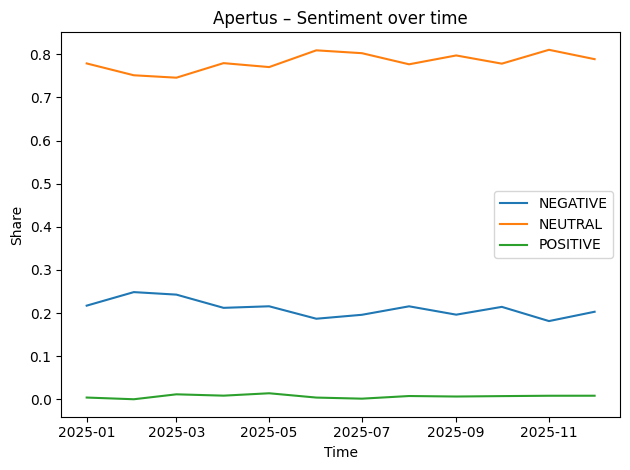

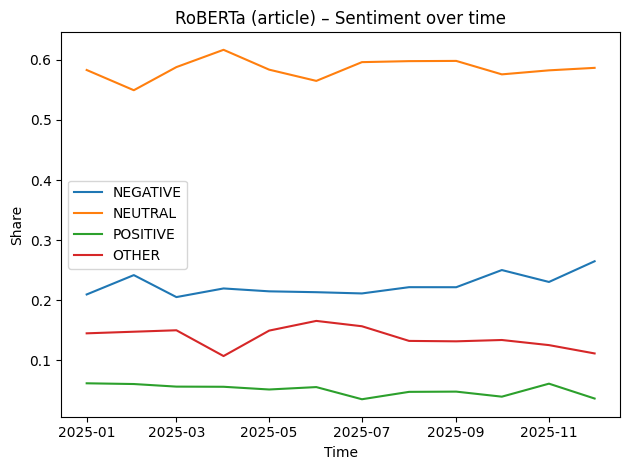

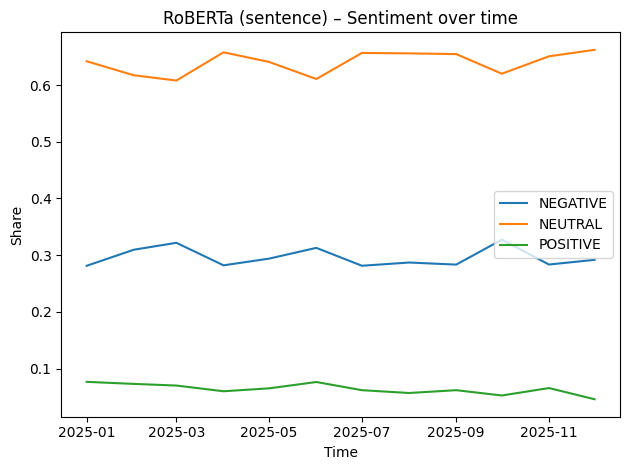

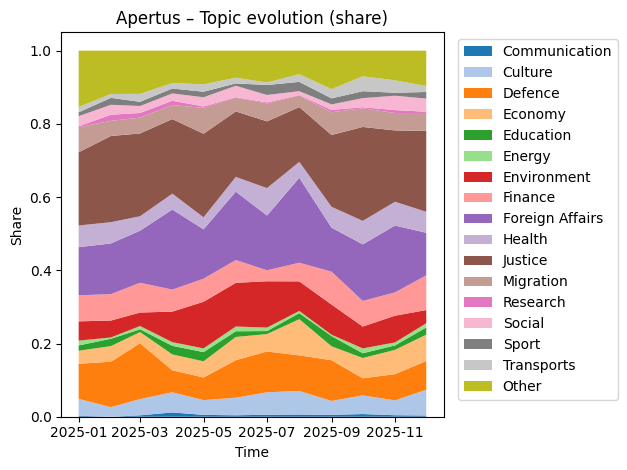

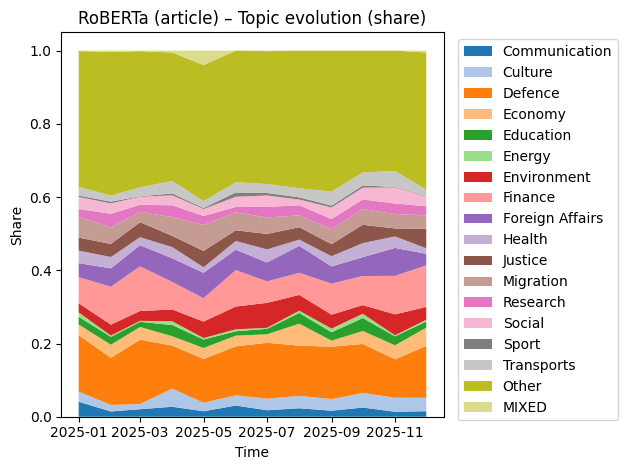

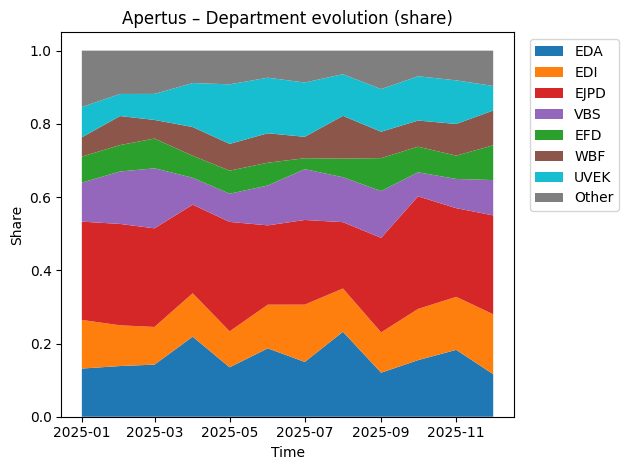

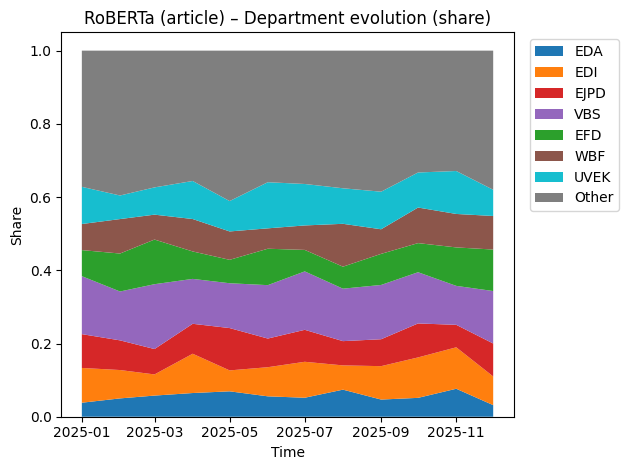

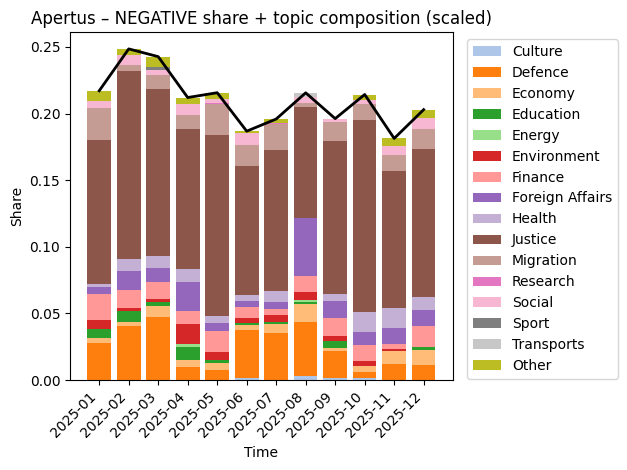

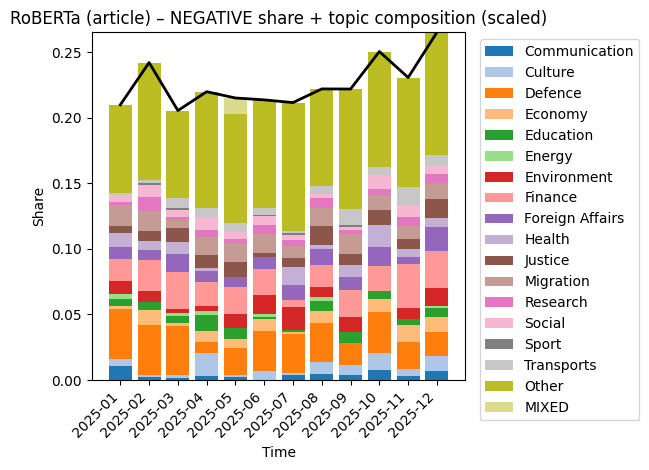

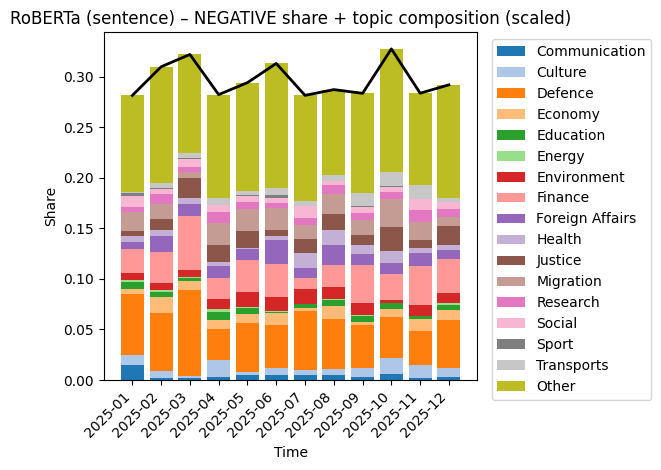

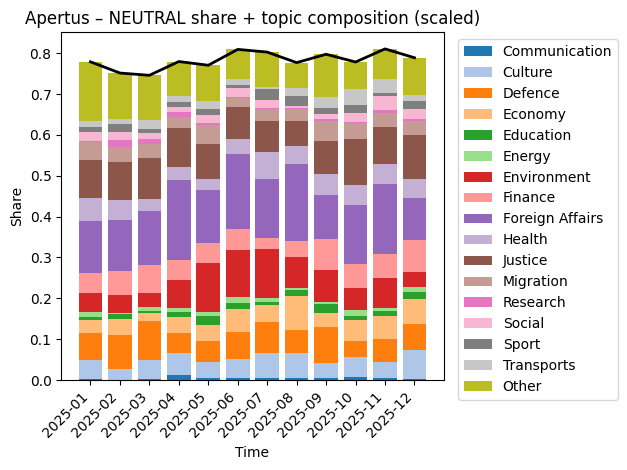

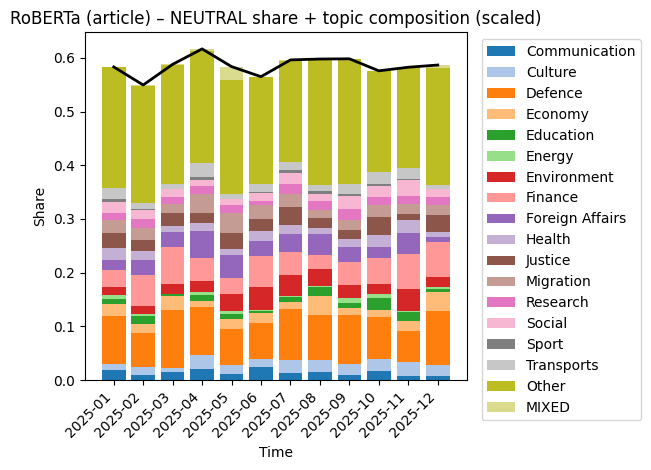

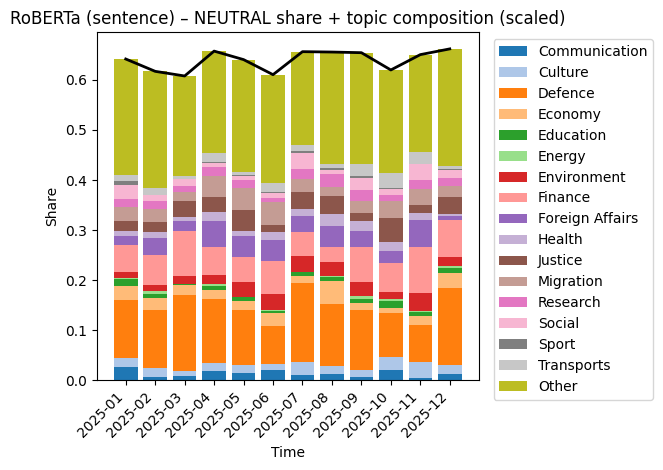

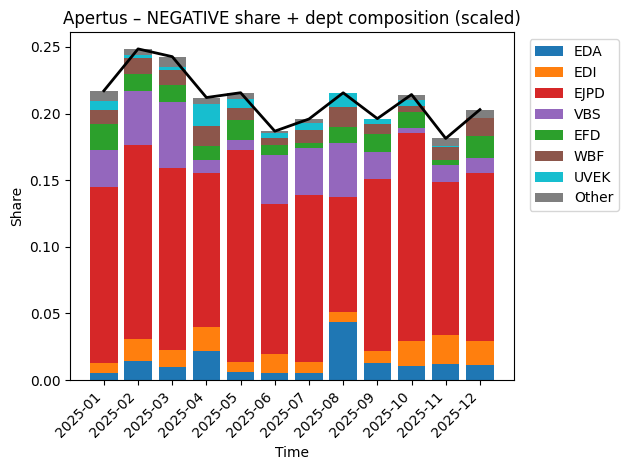

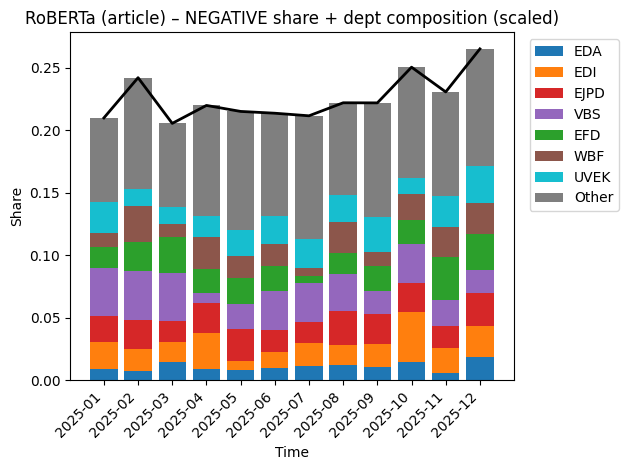

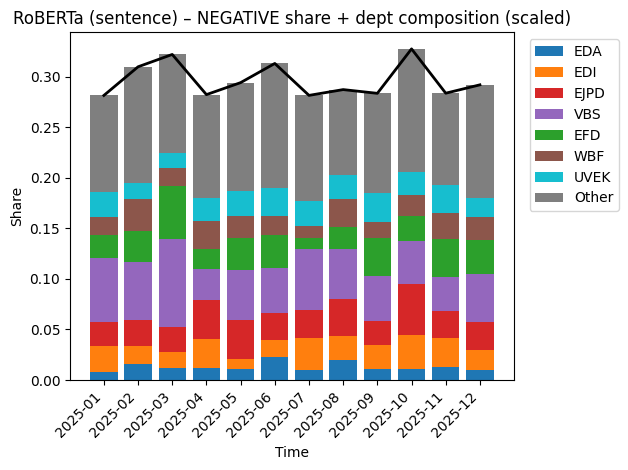

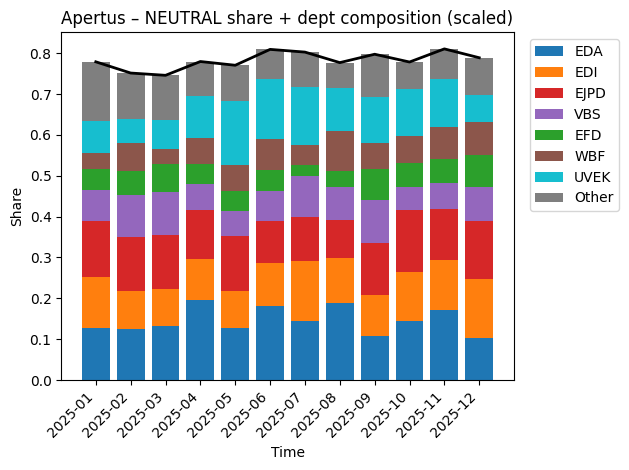

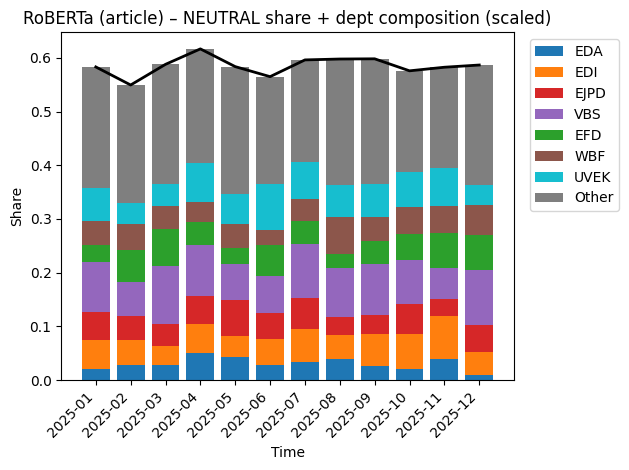

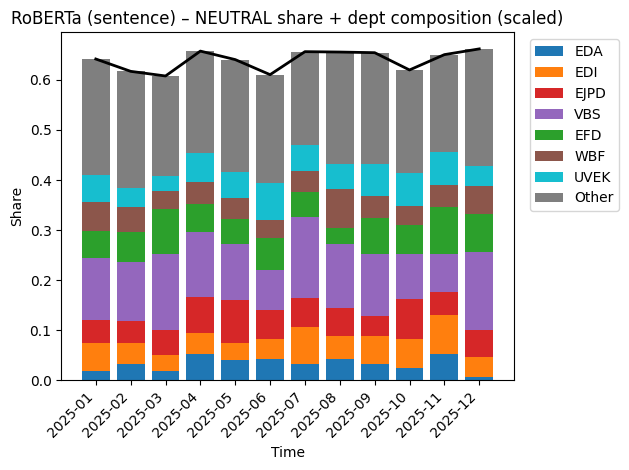

In [4]:
# ============================================================
# ONE-CELL, CLEAN + FAST PLOTTING SUITE (matplotlib only)
# - pubtime -> period
# - stable colors (no duplicates / no random switching)
# - scaled NEG/NEU composition (stack sums to curve)
# - option: AREA or BARS for the "curve + composition" plots
# - minimal recomputation: pre-aggregates once per dataset
#
# Requires existing DataFrames:
#   df_apertus, df_article_roberta, df_sentences
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------- CONFIG -------------------
DATE_COL = "pubtime"
TIME_FREQ = "M"  # "M" monthly, "W" weekly, "Q" quarterly

# APERTUS
AP_TOPIC_COL = "topic_llm"
AP_SENT_COL  = "sentiment_public_admin_llm"

# ROBERTA - ARTICLE LEVEL
RB_TOPIC_COL_ART = "dominant_theme_roberta"
RB_SENT_COL_ART  = "dominant_sentiment_roberta"

# ROBERTA - SENTENCE LEVEL
RB_TOPIC_COL_SENT = "main_theme"
RB_SENT_COL_SENT  = "sentiment_label"

SENT_ORDER = ["NEGATIVE", "NEUTRAL", "POSITIVE", "MIXED"]

TOPIC_TO_DEPT = {
    "Foreign Affairs": "EDA",
    "Culture": "EDI", "Health": "EDI", "Social": "EDI",
    "Justice": "EJPD", "Migration": "EJPD",
    "Defence": "VBS", "Sport": "VBS",
    "Finance": "EFD",
    "Economy": "WBF", "Education": "WBF", "Research": "WBF",
    "Environment": "UVEK", "Transports": "UVEK", "Energy": "UVEK", "Communication": "UVEK",
    "Other": "Other",
}

DEPT_ORDER = ["EDA","EDI","EJPD","VBS","EFD","WBF","UVEK","Other"]

# Choose how to render NEG/NEU composition:
#   "area" = stacked area under curve
#   "bars" = stacked bars (recommended for readability)
COMPOSITION_STYLE = "bars"  # "area" or "bars"

# ------------------- BASIC CHECKS -------------------
def _require_cols(df, cols, name):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"[{name}] Missing columns: {missing}. Found: {list(df.columns)}")

_require_cols(df_apertus,         [DATE_COL, AP_TOPIC_COL, AP_SENT_COL], "df_apertus")
_require_cols(df_article_roberta, [DATE_COL, RB_TOPIC_COL_ART, RB_SENT_COL_ART], "df_article_roberta")
_require_cols(df_sentences,       [DATE_COL, RB_TOPIC_COL_SENT, RB_SENT_COL_SENT], "df_sentences")

# ------------------- PREP (FAST, minimal copies) -------------------
def _prep(df, topic_col, sent_col):
    out = df[[DATE_COL, topic_col, sent_col]].copy()

    # date -> period
    out[DATE_COL] = pd.to_datetime(out[DATE_COL], errors="coerce")
    out = out.dropna(subset=[DATE_COL])
    out["period"] = out[DATE_COL].dt.to_period(TIME_FREQ).dt.to_timestamp()

    # normalize labels (fast ops only)
    out[topic_col] = (out[topic_col].astype(str).str.strip().str.replace(r"\s+", " ", regex=True)
                      .replace({"Others": "Other"}))
    out[sent_col]  = (out[sent_col].astype(str).str.strip().str.upper().str.replace(r"\s+", " ", regex=True)
                      .replace({"NEG":"NEGATIVE","NEU":"NEUTRAL","POS":"POSITIVE"}))

    return out

ap   = _prep(df_apertus,         AP_TOPIC_COL,      AP_SENT_COL)
rb_a = _prep(df_article_roberta, RB_TOPIC_COL_ART,  RB_SENT_COL_ART)
rb_s = _prep(df_sentences,       RB_TOPIC_COL_SENT, RB_SENT_COL_SENT)

# add dept columns (no copy explosion)
ap["dept"]   = ap[AP_TOPIC_COL].map(TOPIC_TO_DEPT).fillna("Other")
rb_a["dept"] = rb_a[RB_TOPIC_COL_ART].map(TOPIC_TO_DEPT).fillna("Other")
rb_s["dept"] = rb_s[RB_TOPIC_COL_SENT].map(TOPIC_TO_DEPT).fillna("Other")

# ------------------- STABLE COLORS -------------------
def _make_color_map(labels, cmap_name="tab20"):
    cmap = plt.get_cmap(cmap_name)
    return {lab: cmap(i % cmap.N) for i, lab in enumerate(labels)}

# topic order = union across datasets, stable alphabetical with "Other/MIXED" at end
all_topics = sorted(
    set(ap[AP_TOPIC_COL].dropna().unique())
    | set(rb_a[RB_TOPIC_COL_ART].dropna().unique())
    | set(rb_s[RB_TOPIC_COL_SENT].dropna().unique())
)
# push common catch-alls at end
for tail in ["Other", "MIXED"]:
    if tail in all_topics:
        all_topics.remove(tail)
        all_topics.append(tail)

TOPIC_COLORS = _make_color_map(all_topics, "tab20")
DEPT_COLORS = {
    "EDA":  "#1f77b4",
    "EDI":  "#ff7f0e",
    "EJPD": "#d62728",
    "VBS":  "#9467bd",
    "EFD":  "#2ca02c",
    "WBF":  "#8c564b",
    "UVEK": "#17becf",
    "Other":"#7f7f7f",
}

# ------------------- AGGREGATION HELPERS (compute once per dataset) -------------------
def _shares_over_time(df, cat_col):
    tab = df.groupby(["period", cat_col]).size().unstack(fill_value=0)
    denom = tab.sum(axis=1).replace(0, np.nan)
    return tab.div(denom, axis=0).fillna(0)

def _curve_and_scaled_comp(df, sent_col, target_sent, stack_col):
    # curve = share(target_sent) over total per period
    total = df.groupby("period").size()
    target = df[df[sent_col] == target_sent].groupby("period").size()
    curve = (target / total).reindex(total.index).fillna(0)

    # comp within target_sent, scaled to curve
    comp = (
        df[df[sent_col] == target_sent]
        .groupby(["period", stack_col]).size()
        .unstack(fill_value=0)
        .reindex(total.index).fillna(0)
    )
    comp_shares = comp.div(comp.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
    scaled = comp_shares.mul(curve, axis=0)
    return curve, scaled

# Precompute once (fast)
ap_sent_share   = _shares_over_time(ap,   AP_SENT_COL)
rb_a_sent_share = _shares_over_time(rb_a, RB_SENT_COL_ART)
rb_s_sent_share = _shares_over_time(rb_s, RB_SENT_COL_SENT)

ap_topic_share   = _shares_over_time(ap,   AP_TOPIC_COL)
rb_a_topic_share = _shares_over_time(rb_a, RB_TOPIC_COL_ART)

ap_dept_share   = _shares_over_time(ap,   "dept").reindex(columns=DEPT_ORDER, fill_value=0)
rb_a_dept_share = _shares_over_time(rb_a, "dept").reindex(columns=DEPT_ORDER, fill_value=0)

# ------------------- PLOTTING (small, predictable, no heavy loops) -------------------
def plot_sentiment_lines(share_df, title):
    plt.figure()
    cols = [c for c in SENT_ORDER if c in share_df.columns] + [c for c in share_df.columns if c not in SENT_ORDER]
    for c in cols:
        plt.plot(share_df.index, share_df[c], label=c)
    plt.title(title)
    plt.ylabel("Share")
    plt.xlabel("Time")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_stack_area(share_df, title, color_map=None):
    share_df = share_df.copy()
    cols = [c for c in share_df.columns if share_df[c].sum() > 0]
    share_df = share_df[cols]
    colors = [color_map.get(c, "#cccccc") for c in cols] if color_map else None

    plt.figure()
    plt.stackplot(share_df.index, share_df.T, colors=colors)
    plt.title(title)
    plt.ylabel("Share")
    plt.xlabel("Time")
    plt.legend(cols, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

def plot_curve_comp(curve, scaled_df, title, color_map=None, style="bars"):
    # keep non-empty columns, stable order
    cols = [c for c in scaled_df.columns if scaled_df[c].sum() > 0]
    scaled = scaled_df[cols]

    if style == "area":
        fig, ax = plt.subplots()
        ax.plot(curve.index, curve.values, color="black", linewidth=2.0, label="_nolegend_")
        colors = [color_map.get(c, "#cccccc") for c in cols] if color_map else None
        ax.stackplot(scaled.index, scaled.T, alpha=0.7, colors=colors)
        ax.set_title(title)
        ax.set_ylabel("Share")
        ax.set_xlabel("Time")
        ax.legend(cols, bbox_to_anchor=(1.02, 1), loc="upper left")
        plt.tight_layout()
        plt.show()
        return

    # bars (recommended)
    fig, ax = plt.subplots()
    x = np.arange(len(scaled.index))
    bottom = np.zeros(len(scaled.index))

    for c in cols:
        color = color_map.get(c, "#cccccc") if color_map else None
        ax.bar(x, scaled[c].values, bottom=bottom, label=c, color=color)
        bottom += scaled[c].values

    ax.plot(x, curve.values, color="black", linewidth=2.0, label="_nolegend_")  # outline of total
    ax.set_title(title)
    ax.set_ylabel("Share")
    ax.set_xlabel("Time")
    ax.set_xticks(x)
    ax.set_xticklabels([d.strftime("%Y-%m") for d in scaled.index], rotation=45, ha="right")
    ax.legend(cols, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

# ============================================================
# 1) Sentiment over time (3)
# ============================================================
plot_sentiment_lines(ap_sent_share,   "Apertus – Sentiment over time")
plot_sentiment_lines(rb_a_sent_share, "RoBERTa (article) – Sentiment over time")
plot_sentiment_lines(rb_s_sent_share, "RoBERTa (sentence) – Sentiment over time")

# ============================================================
# 2) Topic evolution (Apertus + Roberta article) (2)
# ============================================================
plot_stack_area(ap_topic_share.reindex(columns=all_topics, fill_value=0),   "Apertus – Topic evolution (share)", color_map=TOPIC_COLORS)
plot_stack_area(rb_a_topic_share.reindex(columns=all_topics, fill_value=0), "RoBERTa (article) – Topic evolution (share)", color_map=TOPIC_COLORS)

# ============================================================
# 3) Department evolution (Apertus + Roberta article) (2)
# ============================================================
plot_stack_area(ap_dept_share,   "Apertus – Department evolution (share)", color_map=DEPT_COLORS)
plot_stack_area(rb_a_dept_share, "RoBERTa (article) – Department evolution (share)", color_map=DEPT_COLORS)

# ============================================================
# 4) NEG/NEU curve + TOPIC composition (A / R-art / R-sent) (6)
# ============================================================
for target_sent in ["NEGATIVE", "NEUTRAL"]:
    # Apertus
    curve, scaled = _curve_and_scaled_comp(ap, AP_SENT_COL, target_sent, AP_TOPIC_COL)
    plot_curve_comp(curve, scaled.reindex(columns=all_topics, fill_value=0),
                    f"Apertus – {target_sent} share + topic composition (scaled)", TOPIC_COLORS, style=COMPOSITION_STYLE)

    # Roberta article
    curve, scaled = _curve_and_scaled_comp(rb_a, RB_SENT_COL_ART, target_sent, RB_TOPIC_COL_ART)
    plot_curve_comp(curve, scaled.reindex(columns=all_topics, fill_value=0),
                    f"RoBERTa (article) – {target_sent} share + topic composition (scaled)", TOPIC_COLORS, style=COMPOSITION_STYLE)

    # Roberta sentence
    curve, scaled = _curve_and_scaled_comp(rb_s, RB_SENT_COL_SENT, target_sent, RB_TOPIC_COL_SENT)
    plot_curve_comp(curve, scaled.reindex(columns=all_topics, fill_value=0),
                    f"RoBERTa (sentence) – {target_sent} share + topic composition (scaled)", TOPIC_COLORS, style=COMPOSITION_STYLE)

# ============================================================
# 5) NEG/NEU curve + DEPT composition (A / R-art / R-sent) (6)
# ============================================================
for target_sent in ["NEGATIVE", "NEUTRAL"]:
    # Apertus
    curve, scaled = _curve_and_scaled_comp(ap, AP_SENT_COL, target_sent, "dept")
    plot_curve_comp(curve, scaled.reindex(columns=DEPT_ORDER, fill_value=0),
                    f"Apertus – {target_sent} share + dept composition (scaled)", DEPT_COLORS, style=COMPOSITION_STYLE)

    # Roberta article
    curve, scaled = _curve_and_scaled_comp(rb_a, RB_SENT_COL_ART, target_sent, "dept")
    plot_curve_comp(curve, scaled.reindex(columns=DEPT_ORDER, fill_value=0),
                    f"RoBERTa (article) – {target_sent} share + dept composition (scaled)", DEPT_COLORS, style=COMPOSITION_STYLE)

    # Roberta sentence
    curve, scaled = _curve_and_scaled_comp(rb_s, RB_SENT_COL_SENT, target_sent, "dept")
    plot_curve_comp(curve, scaled.reindex(columns=DEPT_ORDER, fill_value=0),
                    f"RoBERTa (sentence) – {target_sent} share + dept composition (scaled)", DEPT_COLORS, style=COMPOSITION_STYLE)
